# 04c · 밀(wheat) 수확량 예측 모델

04(옥수수)·04b(대두)와 **완전히 동일한 파이프라인**으로 밀 모델을 만든다.
타깃만 `wheat` 으로 바꾸고 나머지는 그대로 — 같은 피처 공간, 같은 `GroupKFold(stco)` 평가,
같은 제약(slope 제외, 타깃 누출 피처 금지).

10(3작물 최적화)에서 옥수수·대두와 나란히 놓고 비교하려면 **같은 조건에서 학습**해야 한다.

## ⚠ 밀 데이터의 구조적 한계 — 시작 전에 명시

| | 옥수수 | 대두 | **밀** |
|---|---|---|---|
| 관측 연도 | 1981–2015 | 1981–2015 | **1981–2007** |
| 관측 행 수 | 70,721 | 56,960 | **55,848** |
| 카운티 수 | 2,644 | 2,169 | **2,675** |

`yielddata.csv` 의 밀은 **2008년 이후 관측이 전혀 없다**(0건). 즉 밀 모델은 다른 두 작물보다
**8년 짧은 기간**으로 학습된다. 이것이 낳는 문제:

1. **year 외삽.** 05/06은 시나리오를 `year = 2015` 로 넣는다. 그런데 밀 모델의 학습 범위는
   2007까지다. 트리 모델은 외삽하지 못하므로 `year = 2015` 를 넣어도 사실상 **2007년 기술 수준**의
   예측을 낸다. 옥수수·대두는 2015년 기술로 예측되는데 밀만 2007년에 묶인다 →
   **밀이 체계적으로 과소평가된다.** §5에서 이 편향의 크기를 정량화한다.
2. **생육창 불일치.** 우리가 쓰는 온도 노출은 **3–8월(MarAug)** 이다. 이는 옥수수 기준 생육창이고,
   미국 밀의 주력인 **겨울밀은 가을에 심어 6–7월에 수확**한다. 즉 밀의 실제 생육창과
   피처의 시간창이 어긋난다. §6에서 다룬다.

이 두 가지는 밀 모델의 **본질적 한계**이며, 3작물 최적화의 결론을 읽을 때 반드시 감안해야 한다.

In [1]:
import json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import partial_dependence

RAW  = Path('..') / 'data' / 'raw'          # 읽기 전용 (수정 금지)
PROC = Path('..') / 'data' / 'processed'
FIG  = Path('..') / 'outputs' / 'figures'
RES  = Path('..') / 'outputs' / 'results'

SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = '#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948'
CORN_C, SOY_C, WHEAT_C = '#eda100', '#1baf7a', '#a0522d'      # 옥수수=노랑 대두=초록 밀=갈색

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'semibold',
    'axes.labelsize': 10.5, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

MISSING = []
try:
    import xgboost as xgb
except Exception as e:
    xgb = None; MISSING.append('XGBoost')
try:
    import lightgbm as lgb
except Exception as e:
    lgb = None; MISSING.append('LightGBM')
try:
    from catboost import CatBoostRegressor
except Exception as e:
    CatBoostRegressor = None; MISSING.append('CatBoost')
print('사용 불가 모델:', MISSING if MISSING else '없음')

사용 불가 모델: 없음


## 1. 밀 패널 구성 — 04b와 동일한 절차, 타깃만 wheat

In [2]:
ERA_BINS = [(1981, 1995, 1992), (1996, 2003, 2001), (2004, 2008, 2006), (2009, 2015, 2011)]
def year_to_era(y):
    for lo, hi, era in ERA_BINS:
        if lo <= y <= hi:
            return era
    return np.nan

DAYS = 184.0

yld = pd.read_csv(RAW / 'yielddata.csv')
print('yielddata:', yld.shape)
w = yld[yld.wheat.notna()]
print('밀 관측: %d행 · %d 카운티 · %d~%d년' % (len(w), w.stco.nunique(), w.year.min(), w.year.max()))
print('연도별 밀 관측 수 (2005~2010):')
print(yld[yld.year.between(2005, 2010)].groupby('year')['wheat'].count().to_string())
print('  → 2008년부터 0건. 밀 모델은 1981-2007 로만 학습된다.')

base = yld[['stco', 'year', 'corn', 'soybean', 'wheat']].copy()
base['era'] = base['year'].apply(year_to_era)

gdd = pd.read_csv(RAW / 'gddMarAug.csv').dropna(subset=['year'])
gdd['year'] = gdd['year'].astype(int)
GDD = [c for c in gdd.columns if c not in ('stco', 'year')]

ppt = pd.read_csv(RAW / 'pptMarAug.csv').dropna(subset=['year'])
ppt['year'] = ppt['year'].astype(int)

soil_all = pd.concat([pd.read_csv(RAW / ('soil%d.csv' % era)).assign(era=era)
                      for era in (1992, 2001, 2006, 2011)], ignore_index=True)

grid = pd.read_csv(RAW / 'gridInfo.csv')
num_cols = ['numAg1992', 'numAg2001', 'numAg2006', 'numAg2011']
ac = (grid.groupby('stco', as_index=False)[num_cols].sum()
          .melt(id_vars='stco', value_vars=num_cols, var_name='numcol', value_name='A_c'))
ac['era'] = ac['numcol'].str.replace('numAg', '').astype(int)
ac = ac.drop(columns='numcol')

panel = (base.merge(gdd, on=['stco', 'year'], how='left')
              .merge(ppt, on=['stco', 'year'], how='left')
              .merge(soil_all, on=['stco', 'era'], how='left')
              .merge(ac, on=['stco', 'era'], how='left'))
print('\n머지 후:', panel.shape)

n0 = len(panel)
df = panel.dropna(subset=['wheat']).reset_index(drop=True)
print('wheat NA 제거: %d -> %d 행 (제거 %d)' % (n0, len(df), n0 - len(df)))

corn_counties  = set(panel.dropna(subset=['corn']).stco.unique())
soy_counties   = set(panel.dropna(subset=['soybean']).stco.unique())
wheat_counties = set(df.stco.unique())
print()
print('옥수수 : %d 카운티' % len(corn_counties))
print('대두   : %d 카운티' % len(soy_counties))
print('밀     : %d 카운티' % len(wheat_counties))
print('세 작물 모두 재배 : %d 카운티  ← 10의 3작물 최적화 후보' % len(corn_counties & soy_counties & wheat_counties))

yielddata: (107450, 6)
밀 관측: 55848행 · 2675 카운티 · 1981~2007년
연도별 밀 관측 수 (2005~2010):
year
2005    1652
2006    1598
2007    1602
2008       0
2009       0
2010       0
  → 2008년부터 0건. 밀 모델은 1981-2007 로만 학습된다.



머지 후: (107450, 139)
wheat NA 제거: 107450 -> 55848 행 (제거 51602)



옥수수 : 2644 카운티
대두   : 2169 카운티
밀     : 2675 카운티
세 작물 모두 재배 : 2056 카운티  ← 10의 3작물 최적화 후보


In [3]:
# --- 날씨가 통째로 없는 행 제거 (밀 패널에만 있는 경우) ---
# gddMarAug/pptMarAug 는 year 결측 행을 버렸으므로, 일부 (stco, year) 는 날씨가 아예 붙지 않는다.
# 옥수수·대두 패널에는 없었지만 밀 패널에는 존재한다. 184 복원 공식은 전부 NaN 이면 못 쓴다.
no_weather = df[GDD].isna().all(axis=1) | df['ppt'].isna()
if no_weather.any():
    print('날씨 전무 행 제거: %d행 (%s)'
          % (int(no_weather.sum()),
             df.loc[no_weather, ['stco', 'year']].to_dict('records')))
    df = df[~no_weather].reset_index(drop=True)

# --- 03/04b와 동일한 결측 처리 ---
na_g = df['gddm4'].isna()
others = [c for c in GDD if c != 'gddm4']
if na_g.any():
    df.loc[na_g, 'gddm4'] = DAYS - df.loc[na_g, others].sum(axis=1)
    print('gddm4 결측 %d행 복원 (184 - 나머지합)' % int(na_g.sum()))

SOIL_MEDIAN = ['whc', 'sand', 'clay', 'om', 'kwfactor', 'kffactor', 'spH', 'tfactor']
n_med = int(df[SOIL_MEDIAN].isna().sum().sum())
df[SOIL_MEDIAN] = df[SOIL_MEDIAN].fillna(df[SOIL_MEDIAN].median())
n_silt = int(df['silt'].isna().sum())
df['silt'] = df['silt'].fillna(100.0 - df['sand'] - df['clay'])
print('soil 대체: 중앙값 %d셀 + silt %d셀(=100-sand-clay)' % (n_med, n_silt))
print('slope 결측 %d행 -> slope 자체를 쓰지 않으므로 대체 안 함 (04/04b 규칙)' % int(df['slope'].isna().sum()))

assert np.allclose(df[['sand', 'silt', 'clay']].sum(axis=1), 100.0), '텍스처 제약 위반'
assert df[GDD + SOIL_MEDIAN + ['silt', 'ppt']].isna().sum().sum() == 0
print('결측 처리 후 남은 결측: 0')

row_sum = df[GDD].sum(axis=1)
bad = int((np.abs(row_sum - DAYS) > 0.1).sum())
print('gdd 121구간 행별 합: mean %.4f std %.5f | |합-184|>0.1 인 행 %d개 (%.2f%%)'
      % (row_sum.mean(), row_sum.std(), bad, 100 * bad / len(df)))

날씨 전무 행 제거: 1행 ([{'stco': 8111, 'year': 1999}])


soil 대체: 중앙값 16셀 + silt 2셀(=100-sand-clay)
slope 결측 2403행 -> slope 자체를 쓰지 않으므로 대체 안 함 (04/04b 규칙)


결측 처리 후 남은 결측: 0


gdd 121구간 행별 합: mean 183.9996 std 0.01167 | |합-184|>0.1 인 행 55개 (0.10%)


In [4]:
# --- 03/04b와 동일한 피처 생성 ---
spec = json.load(open(PROC / 'feature_columns.json', encoding='utf-8'))
SOIL       = spec['strategy_A']['soil']
CANON      = spec['strategy_A']['canonical_threshold']
THRESHOLDS = spec['strategy_A']['thresholds_available']
GDD_BINS   = spec['strategy_B']['gdd_bins']
REF_BIN    = spec['strategy_B']['reference_bin_dropped']

def temp_of(c):
    return 0 if c == 'gdd0' else (int(c[4:]) if c.startswith('gddp') else -int(c[4:]))

df['ppt_sq']   = df['ppt'] ** 2
df['wheat_dm'] = df['wheat'] - df.groupby('year')['wheat'].transform('mean')   # 해석용

for t in THRESHOLDS:
    bel = [c for c in GDD if c.startswith('gddp') and 1 <= temp_of(c) <= t]
    abv = [c for c in GDD if c.startswith('gddp') and temp_of(c) > t]
    df['GDD_below_%d' % t] = df[bel].sum(axis=1)
    df['GDD_above_%d' % t] = df[abv].sum(axis=1)
df['GDD_cold'] = df[[c for c in GDD if temp_of(c) <= 0]].sum(axis=1)

chk = df['GDD_below_29'] + df['GDD_above_29'] + df['GDD_cold']
print('below29 + above29 + cold = %.3f (std %.4f) → 184 복원 확인' % (chk.mean(), chk.std()))

excluded = [c for c in GDD if c not in GDD_BINS and c != REF_BIN]
extra = df[excluded].sum(); extra = extra[extra > 0]
print('03이 제외한 구간 중 밀 패널에서 노출이 생긴 구간: %s'
      % (extra.to_dict() if len(extra) else '없음 → 피처공간 동일'))

KEYS    = ['stco', 'year']
TARGETS = ['wheat', 'wheat_dm']
CARRY   = ['A_c', 'corn', 'soybean', 'silt', 'GDD_cold']
gdd_pairs = [('GDD_%s_%d' % (s, t)) for t in THRESHOLDS for s in ('below', 'above')]
out_cols = KEYS + TARGETS + CARRY + gdd_pairs + GDD_BINS + ['ppt', 'ppt_sq'] + SOIL
wheat_panel = df[out_cols].copy()
wheat_panel.to_parquet(PROC / 'wheat_panel.parquet', index=False)
print('\n저장: %s  %s' % (PROC / 'wheat_panel.parquet', wheat_panel.shape))
print('밀 수확량: mean %.1f  std %.1f  min %.1f  max %.1f (bu/ac)'
      % (df.wheat.mean(), df.wheat.std(), df.wheat.min(), df.wheat.max()))

below29 + above29 + cold = 184.000 (std 0.0117) → 184 복원 확인
03이 제외한 구간 중 밀 패널에서 노출이 생긴 구간: {'gddm37': 6.89805734873754e-06, 'gddp51': 1.29480289347589e-05}



저장: ..\data\processed\wheat_panel.parquet  (55847, 113)
밀 수확량: mean 42.3  std 15.8  min 0.0  max 127.8 (bu/ac)


## 2. 피처셋 — 04/04b와 문자 그대로 동일한지 검증

In [5]:
FEAT_A = ['year', 'GDD_below_%d' % CANON, 'GDD_above_%d' % CANON, 'ppt', 'ppt_sq'] + SOIL
FEAT_B = ['year'] + GDD_BINS + ['ppt', 'ppt_sq'] + SOIL

BANNED = {'slope', 'slope_missing', 'wheat', 'wheat_dm', 'corn', 'soybean',
          'corn_dm', 'soy_dm', 'A_c', 'GDD_cold', 'silt', 'stco'}
for tag, F in [('A', FEAT_A), ('B', FEAT_B)]:
    assert not (BANNED & set(F)), '금지 컬럼이 피처에 있음'
    assert len(F) == len(set(F)), '중복 컬럼'
print('제약 검증 통과: slope 제외 · 타깃 누출 피처 없음')

corn_bundle = joblib.load(PROC / 'yield_model_final.joblib')
soy_bundle  = joblib.load(PROC / 'soybean_model_final.joblib')
assert list(corn_bundle['features']) == FEAT_B, '04와 피처가 다르다'
assert list(soy_bundle['features'])  == FEAT_B, '04b와 피처가 다르다'
print('=> 04(옥수수)·04b(대두)와 피처 리스트 완전 일치 (%d개) — 같은 공간에서 학습' % len(FEAT_B))

y      = wheat_panel['wheat'].to_numpy(float)
groups = wheat_panel['stco'].to_numpy()
XA, XB = wheat_panel[FEAT_A].copy(), wheat_panel[FEAT_B].copy()
print('\nFEAT_A %d개 | FEAT_B %d개' % (len(FEAT_A), len(FEAT_B)))
print('타깃 wheat: mean %.1f  std %.1f  n=%d  counties=%d  years %d-%d'
      % (y.mean(), y.std(), len(y), wheat_panel.stco.nunique(),
         wheat_panel.year.min(), wheat_panel.year.max()))

제약 검증 통과: slope 제외 · 타깃 누출 피처 없음
=> 04(옥수수)·04b(대두)와 피처 리스트 완전 일치 (97개) — 같은 공간에서 학습

FEAT_A 13개 | FEAT_B 97개
타깃 wheat: mean 42.3  std 15.8  n=55847  counties=2674  years 1981-2007


## 3. 9개 모델 × 2개 전략 — 04/04b와 동일한 GroupKFold(stco) 5-fold

In [6]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

def cv_eval(name, factory, X, yv, grp):
    oof = np.full(len(yv), np.nan)
    r2s, rmses, maes = [], [], []
    t0 = time.time()
    for tr, te in gkf.split(X, yv, grp):
        m = factory()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            m.fit(X.iloc[tr], yv[tr])
            p = m.predict(X.iloc[te])
        oof[te] = p
        r2s.append(r2_score(yv[te], p)); rmses.append(rmse(yv[te], p))
        maes.append(mean_absolute_error(yv[te], p))
    return {'model': name, 'r2_mean': np.mean(r2s), 'r2_std': np.std(r2s),
            'rmse_mean': np.mean(rmses), 'rmse_std': np.std(rmses),
            'mae_mean': np.mean(maes), 'mae_std': np.std(maes),
            'r2_folds': '|'.join('%.3f' % v for v in r2s),
            'seconds': time.time() - t0}, oof

def build_factories():
    f = {
        'OLS':          lambda: make_pipeline(StandardScaler(), LinearRegression()),
        'Ridge':        lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 25))),
        'Lasso':        lambda: make_pipeline(StandardScaler(), LassoCV(cv=3, n_jobs=-1, random_state=0, max_iter=5000)),
        'ElasticNet':   lambda: make_pipeline(StandardScaler(), ElasticNetCV(cv=3, l1_ratio=[.2, .5, .8, .95],
                                                                            n_jobs=-1, random_state=0, max_iter=5000)),
        'RandomForest': lambda: RandomForestRegressor(n_estimators=150, min_samples_leaf=5, n_jobs=-1, random_state=0),
        'GradientBoosting': lambda: GradientBoostingRegressor(n_estimators=150, max_depth=3, subsample=0.7, random_state=0),
    }
    if xgb is not None:
        f['XGBoost'] = lambda: xgb.XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.05,
                                                subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                                random_state=0, tree_method='hist')
    if lgb is not None:
        f['LightGBM'] = lambda: lgb.LGBMRegressor(n_estimators=600, num_leaves=63, learning_rate=0.05,
                                                  subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                                  random_state=0, verbose=-1)
    if CatBoostRegressor is not None:
        f['CatBoost'] = lambda: CatBoostRegressor(iterations=800, depth=6, learning_rate=0.05,
                                                  random_seed=0, verbose=0, allow_writing_files=False)
    return f

FACTORIES = build_factories()
print('평가할 모델 %d개: %s' % (len(FACTORIES), list(FACTORIES)))

results, oofs = [], {}
for strat, X in [('A', XA), ('B', XB)]:
    print('\n===== 전략 %s (%d features) =====' % (strat, X.shape[1]))
    for name, fac in FACTORIES.items():
        row, oof = cv_eval(name, fac, X, y, groups)
        row['strategy'] = strat
        results.append(row); oofs[(name, strat)] = oof
        print('  %-17s R2 %.4f ± %.4f | RMSE %6.2f | MAE %5.2f | %5.1fs'
              % (name, row['r2_mean'], row['r2_std'], row['rmse_mean'], row['mae_mean'], row['seconds']))

res = pd.DataFrame(results)[['model', 'strategy', 'r2_mean', 'r2_std', 'rmse_mean', 'rmse_std',
                             'mae_mean', 'mae_std', 'r2_folds', 'seconds']].sort_values('r2_mean', ascending=False)
res.to_csv(RES / 'model_comparison_wheat.csv', index=False)
print('\n저장:', RES / 'model_comparison_wheat.csv')
print()
print(res.drop(columns='r2_folds').round(4).to_string(index=False))

평가할 모델 9개: ['OLS', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']

===== 전략 A (13 features) =====


  OLS               R2 0.2760 ± 0.0213 | RMSE  13.45 | MAE 10.13 |   0.8s


  Ridge             R2 0.2760 ± 0.0213 | RMSE  13.45 | MAE 10.13 |   2.9s


  Lasso             R2 0.2760 ± 0.0213 | RMSE  13.45 | MAE 10.12 |  10.7s


  ElasticNet        R2 0.2759 ± 0.0214 | RMSE  13.46 | MAE 10.12 |  15.3s


...

  RandomForest      R2 0.6824 ± 0.0243 | RMSE   8.90 | MAE  5.96 | 414.1s


  GradientBoosting  R2 0.5442 ± 0.0235 | RMSE  10.67 | MAE  7.87 | 668.7s


  XGBoost           R2 0.6786 ± 0.0250 | RMSE   8.96 | MAE  6.25 |  84.7s


  LightGBM          R2 0.6908 ± 0.0255 | RMSE   8.78 | MAE  6.05 |  57.2s


  CatBoost          R2 0.6519 ± 0.0229 | RMSE   9.32 | MAE  6.65 |  84.9s

저장: ..\outputs\results\model_comparison_wheat.csv

           model strategy  r2_mean  r2_std  rmse_mean  rmse_std  mae_mean  mae_std  seconds
        LightGBM        B   0.6908  0.0255     8.7826    0.3925    6.0478   0.1436  57.2041
    RandomForest        B   0.6824  0.0243     8.9009    0.3463    5.9645   0.1504 414.0805
         XGBoost        B   0.6786  0.0250     8.9554    0.3930    6.2468   0.1585  84.6791
        CatBoost        B   0.6519  0.0229     9.3224    0.3461    6.6484   0.1395  84.8762
        LightGBM        A   0.6442  0.0257     9.4207    0.3076    6.6360   0.1316  12.6873
    RandomForest        A   0.6243  0.0340     9.6755    0.3877    6.5943   0.1538  76.3891
         XGBoost        A   0.6226  0.0315     9.7020    0.4038    6.8662   0.1537   9.9872
        CatBoost        A   0.6133  0.0201     9.8270    0.3011    7.0985   0.1281  30.4389
GradientBoosting        B   0.5442  0.0235    

In [7]:
BEST = res.iloc[0]
BEST_NAME, BEST_STRAT = BEST['model'], BEST['strategy']
print('최고 모델: %s (전략 %s)  R² %.4f · RMSE %.2f bu/ac'
      % (BEST_NAME, BEST_STRAT, BEST['r2_mean'], BEST['rmse_mean']))

X_best = XB if BEST_STRAT == 'B' else XA
F_best = FEAT_B if BEST_STRAT == 'B' else FEAT_A

final_model = FACTORIES[BEST_NAME]()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    final_model.fit(X_best, y)

bundle = {
    'model': final_model, 'model_name': BEST_NAME, 'strategy': BEST_STRAT,
    'features': F_best, 'target': 'wheat',
    'cv': 'GroupKFold(stco, n_splits=%d)' % N_SPLITS,
    'cv_r2_mean': float(BEST['r2_mean']), 'cv_r2_std': float(BEST['r2_std']),
    'cv_rmse_mean': float(BEST['rmse_mean']), 'cv_mae_mean': float(BEST['mae_mean']),
    'n_rows': int(len(y)), 'n_counties': int(wheat_panel.stco.nunique()),
    'y_mean': float(y.mean()),
    'year_range': [int(wheat_panel.year.min()), int(wheat_panel.year.max())],
    'notes': ('04/04b와 동일 피처·동일 하이퍼파라미터·동일 GroupKFold. '
              '⚠ 학습 연도 1981-2007 (2008년 이후 관측 없음). year=2015 예측은 외삽이며 '
              '트리 모델은 사실상 2007년 기술 수준을 반환한다 — 밀이 과소평가된다.'),
}
joblib.dump(bundle, PROC / 'wheat_model_final.joblib')
print('\n저장:', PROC / 'wheat_model_final.joblib')

oof_best = oofs[(BEST_NAME, BEST_STRAT)]
pd.DataFrame({'stco': wheat_panel.stco, 'year': wheat_panel.year,
              'wheat': y, 'y_hat_oof': oof_best}).to_parquet(
    PROC / 'oof_predictions_wheat.parquet', index=False)
print('저장:', PROC / 'oof_predictions_wheat.parquet')
print('OOF 전체 R² = %.4f  RMSE = %.2f' % (r2_score(y, oof_best), rmse(y, oof_best)))

최고 모델: LightGBM (전략 B)  R² 0.6908 · RMSE 8.78 bu/ac



저장: ..\data\processed\wheat_model_final.joblib
저장: ..\data\processed\oof_predictions_wheat.parquet
OOF 전체 R² = 0.6910  RMSE = 8.79


### 그림 1 — 밀 모델 성능 비교 · 예측 vs 실측

saved: ..\outputs\figures\fig41_wheat_model.png


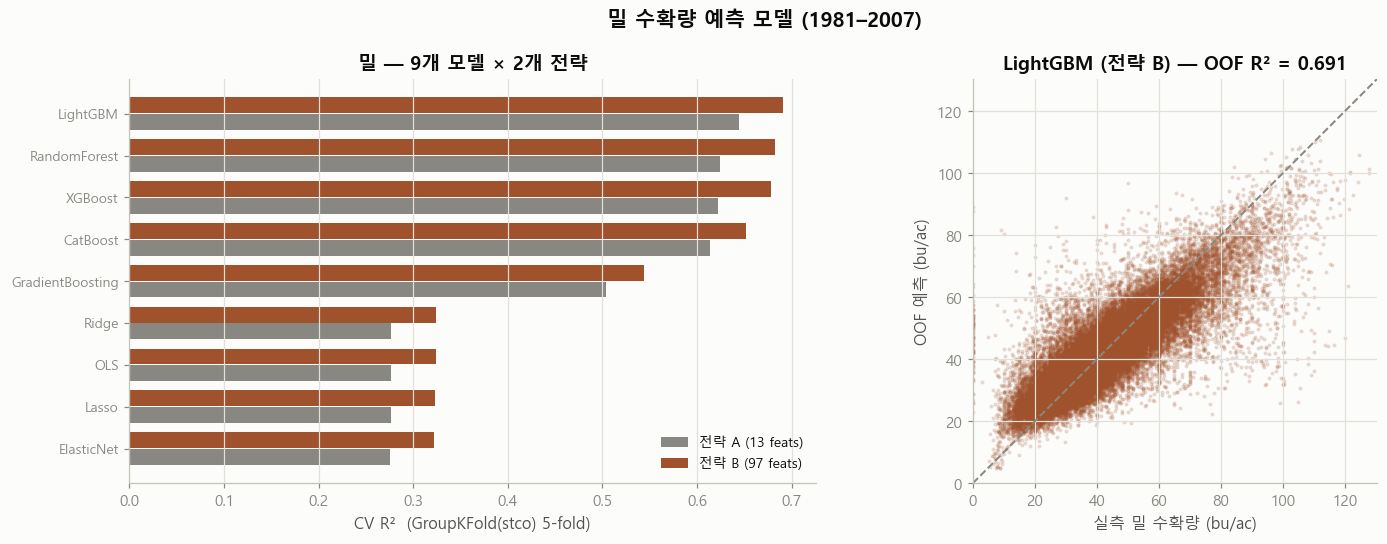

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))

ax = axes[0]
piv = res.pivot(index='model', columns='strategy', values='r2_mean').sort_values('B')
yy = np.arange(len(piv))
ax.barh(yy - 0.2, piv['A'], 0.38, color=MUTED, label='전략 A (13 feats)')
ax.barh(yy + 0.2, piv['B'], 0.38, color=WHEAT_C, label='전략 B (97 feats)')
ax.set_yticks(yy); ax.set_yticklabels(piv.index, fontsize=9)
ax.set_xlabel('CV R²  (GroupKFold(stco) 5-fold)')
ax.set_title('밀 — 9개 모델 × 2개 전략')
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0)

ax = axes[1]
ax.scatter(y, oof_best, s=3, alpha=0.15, color=WHEAT_C)
lim = [0, max(y.max(), oof_best.max()) * 1.02]
ax.plot(lim, lim, color=MUTED, ls='--', lw=1.3)
ax.set_xlabel('실측 밀 수확량 (bu/ac)')
ax.set_ylabel('OOF 예측 (bu/ac)')
ax.set_title('%s (전략 %s) — OOF R² = %.3f' % (BEST_NAME, BEST_STRAT, r2_score(y, oof_best)))
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')

fig.suptitle('밀 수확량 예측 모델 (1981–2007)', fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig41_wheat_model.png'); plt.show()

## 4. 해석용 고정효과 모델 — 밀은 고온에 강한가?

04·04b와 동일하게 카운티·연도 고정효과를 흡수하고, 29℃ 이하 노출 1일을 29℃ 초과로
대체할 때의 효과(대체효과)를 추정한다. **세 작물을 같은 척도로 비교할 수 있는 유일한 지표**다.

In [9]:
P = wheat_panel
ci = pd.factorize(P['stco'])[0]
ti = pd.factorize(P['year'])[0]
nc, nt = ci.max() + 1, ti.max() + 1
cnt_c = np.bincount(ci, minlength=nc).astype(float)
cnt_t = np.bincount(ti, minlength=nt).astype(float)

def demean2(v, iters=500, tol=1e-10):
    v = np.asarray(v, dtype=float).copy()
    for _ in range(iters):
        prev = v.copy()
        v -= (np.bincount(ci, v, minlength=nc) / cnt_c)[ci]
        v -= (np.bincount(ti, v, minlength=nt) / cnt_t)[ti]
        if np.max(np.abs(v - prev)) < tol:
            break
    return v

def within_ols(cols, T):
    Xr = np.column_stack([P[c].to_numpy(float) for c in cols])
    yt = demean2(y)
    Xt = np.column_stack([demean2(Xr[:, j]) for j in range(Xr.shape[1])])
    beta, *_ = np.linalg.lstsq(Xt, yt, rcond=None)
    u = yt - Xt @ beta
    XtX_inv = np.linalg.inv(Xt.T @ Xt)
    meat = np.zeros((len(cols), len(cols)))
    order = np.argsort(ci)
    Xs_, us_, cs_ = Xt[order], u[order], ci[order]
    bounds = np.searchsorted(cs_, np.arange(nc + 1))
    for gI in range(nc):
        a, b = bounds[gI], bounds[gI + 1]
        if b > a:
            s = Xs_[a:b].T @ us_[a:b]
            meat += np.outer(s, s)
    Nn, K = len(y), len(cols)
    K_eff = K + nc + nt - 1
    adj = (nc / (nc - 1)) * ((Nn - 1) / (Nn - K_eff))
    V = XtX_inv @ meat @ XtX_inv * adj
    se = np.sqrt(np.diag(V))
    within_r2 = 1 - (u ** 2).sum() / (yt ** 2).sum()
    c = np.zeros(K); c[cols.index('GDD_above_%d' % T)] = 1.0; c[cols.index('GDD_below_%d' % T)] = -1.0
    subst = float(c @ beta); subst_se = float(np.sqrt(c @ V @ c))
    return beta, se, within_r2, subst, subst_se

rows = []
for T in THRESHOLDS:
    cols = ['GDD_below_%d' % T, 'GDD_above_%d' % T, 'ppt', 'ppt_sq']
    beta, se, wr2, subst, subst_se = within_ols(cols, T)
    rows.append({'T': T, 'b_below': beta[0], 'se_below': se[0], 'b_above': beta[1], 'se_above': se[1],
                 'subst': subst, 'subst_se': subst_se, 'subst_t': subst / subst_se, 'within_R2': wr2})
fe_wheat = pd.DataFrame(rows)
fe_wheat['y_mean'] = y.mean()
fe_wheat['subst_pct'] = 100 * fe_wheat.subst / y.mean()
fe_wheat.to_csv(RES / 'fixed_effects_wheat.csv', index=False)

print('밀 — 카운티 %d + 연도 %d 고정효과 흡수 후 (클러스터 SE: 카운티)' % (nc, nt))
print(fe_wheat.round(4).to_string(index=False))
print('\n저장:', RES / 'fixed_effects_wheat.csv')

밀 — 카운티 2674 + 연도 27 고정효과 흡수 후 (클러스터 SE: 카운티)
 T  b_below  se_below  b_above  se_above   subst  subst_se  subst_t  within_R2  y_mean  subst_pct
28   0.2396     0.015   0.0655    0.0178 -0.1740    0.0079 -21.9885     0.0309 42.3137    -0.4113
29   0.2377     0.015   0.0687    0.0178 -0.1690    0.0081 -20.9021     0.0298 42.3137    -0.3994
30   0.2363     0.015   0.0762    0.0180 -0.1602    0.0085 -18.9113     0.0283 42.3137    -0.3785
31   0.2350     0.015   0.0802    0.0183 -0.1548    0.0090 -17.1313     0.0272 42.3137    -0.3658

저장: ..\outputs\results\fixed_effects_wheat.csv


In [10]:
# 세 작물의 대체효과 비교 (T = 29)
fe_corn = pd.read_csv(RES / 'fixed_effects_coefficients.csv')
fe_soy  = pd.read_csv(RES / 'fixed_effects_soybean.csv')

Y_MEAN = {'옥수수': float(pd.read_parquet(PROC / 'features_stratB.parquet', columns=['corn']).corn.mean()),
          '대두':   float(joblib.load(PROC / 'soybean_model_final.joblib')['y_mean']),
          '밀':     float(y.mean())}

rows = []
for nm, fe in [('옥수수', fe_corn), ('대두', fe_soy), ('밀', fe_wheat)]:
    r = fe[fe['T'] == 29].iloc[0]        # fe.T 는 DataFrame 전치 속성이라 충돌 — fe['T'] 로 접근
    rows.append(dict(작물=nm,
                     평균수확량=Y_MEAN[nm],
                     b_below=r.b_below, b_above=r.b_above,
                     대체효과_bu=r.subst, SE=r.subst_se, t값=r.subst_t,
                     대체효과_pct=100 * r.subst / Y_MEAN[nm],
                     within_R2=r.within_R2))
cmp3 = pd.DataFrame(rows)
print('=' * 78)
print('  세 작물의 고온 민감도 (T = 29℃, 카운티·연도 고정효과)')
print('=' * 78)
print(cmp3.to_string(index=False, float_format='%.4f'))
cmp3.to_csv(RES / 'crop_comparison_3crop.csv', index=False)
print('\n저장:', RES / 'crop_comparison_3crop.csv')

print()
print('해석 — 29℃ 이하 노출 1일을 29℃ 초과로 대체할 때 수확량 변화')
for _, r in cmp3.iterrows():
    print('  %-4s %+7.4f bu/ac/일  (평균 대비 %+.3f%%/일)  t = %.1f'
          % (r.작물, r.대체효과_bu, r.대체효과_pct, r.t값))
print()
srt = cmp3.sort_values('대체효과_pct', ascending=False)
print('  비율 기준 고온 저항성 순위 (덜 잃을수록 강함): %s'
      % ' > '.join(srt.작물.tolist()))

  세 작물의 고온 민감도 (T = 29℃, 카운티·연도 고정효과)
 작물    평균수확량  b_below  b_above  대체효과_bu     SE       t값  대체효과_pct  within_R2
옥수수 108.9062   0.1369  -1.5356  -1.6725 0.0275 -60.7117   -1.5357     0.1532
 대두  33.7028   0.1069  -0.2876  -0.3945 0.0076 -51.7057   -1.1707     0.1620
  밀  42.3137   0.2377   0.0687  -0.1690 0.0081 -20.9021   -0.3994     0.0298

저장: ..\outputs\results\crop_comparison_3crop.csv

해석 — 29℃ 이하 노출 1일을 29℃ 초과로 대체할 때 수확량 변화
  옥수수  -1.6725 bu/ac/일  (평균 대비 -1.536%/일)  t = -60.7
  대두   -0.3945 bu/ac/일  (평균 대비 -1.171%/일)  t = -51.7
  밀    -0.1690 bu/ac/일  (평균 대비 -0.399%/일)  t = -20.9

  비율 기준 고온 저항성 순위 (덜 잃을수록 강함): 밀 > 대두 > 옥수수


### 그림 2 — 세 작물의 온도 반응곡선 비교

04b와 동일한 **제약 반응곡선**(29℃ 이하 노출 1일을 29℃ 초과로 옮기되 총 184일 보존)을
세 작물 모두에 대해 그린다. 절대(bu/ac)와 상대(평균 대비 %) 두 축으로 본다.

In [11]:
TREES = ['LightGBM', 'XGBoost', 'CatBoost', 'RandomForest', 'GradientBoosting']
resA = res[(res.strategy == 'A') & (res.model.isin(TREES))].sort_values('r2_mean', ascending=False)
PDP_NAME = resA.iloc[0]['model']
print('반응곡선용 모델 (전략 A 최고 트리): %s' % PDP_NAME)

cornA = pd.read_parquet(PROC / 'features_stratA.parquet')
soyP  = pd.read_parquet(PROC / 'soybean_panel.parquet')

def response_curve(factory, X, yv, seed=0, n_samp=6000, vmax=70, n_grid=36):
    """제약 반응곡선: below29 → above29 로 하루씩 이동 (총 노출 보존)."""
    m = factory()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        m.fit(X, yv)
    rng = np.random.default_rng(seed)
    samp = rng.choice(len(X), size=min(n_samp, len(X)), replace=False)
    Xs = X.iloc[samp].copy()
    orig_a = Xs['GDD_above_29'].to_numpy().copy()
    orig_b = Xs['GDD_below_29'].to_numpy().copy()
    lo_b, hi_b = np.quantile(X['GDD_below_29'], [0.001, 0.999])
    vs = np.linspace(0, vmax, n_grid)
    curve, nvalid = [], []
    for v in vs:
        X2 = Xs.copy()
        new_b = orig_b + (orig_a - v)
        ok = (new_b >= lo_b) & (new_b <= hi_b)
        X2['GDD_above_29'] = v
        X2['GDD_below_29'] = new_b
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            p = m.predict(X2[ok]) if ok.sum() else np.array([np.nan])
        curve.append(p.mean()); nvalid.append(int(ok.sum()))
    keep = np.array(nvalid) >= 300
    return dict(vs=vs, curve=np.array(curve), keep=keep)

R = {
    '옥수수': response_curve(FACTORIES[PDP_NAME], cornA[FEAT_A].copy(), cornA['corn'].to_numpy(float)),
    '대두':   response_curve(FACTORIES[PDP_NAME], soyP[FEAT_A].copy(),  soyP['soybean'].to_numpy(float)),
    '밀':     response_curve(FACTORIES[PDP_NAME], XA, y),
}
COL = {'옥수수': CORN_C, '대두': SOY_C, '밀': WHEAT_C}
for k, r in R.items():
    print('  %-4s 유효 격자 %d/%d' % (k, r['keep'].sum(), len(r['vs'])))

반응곡선용 모델 (전략 A 최고 트리): LightGBM


  옥수수  유효 격자 36/36
  대두   유효 격자 36/36
  밀    유효 격자 36/36


saved: ..\outputs\figures\fig42_temp_response_3crops.png


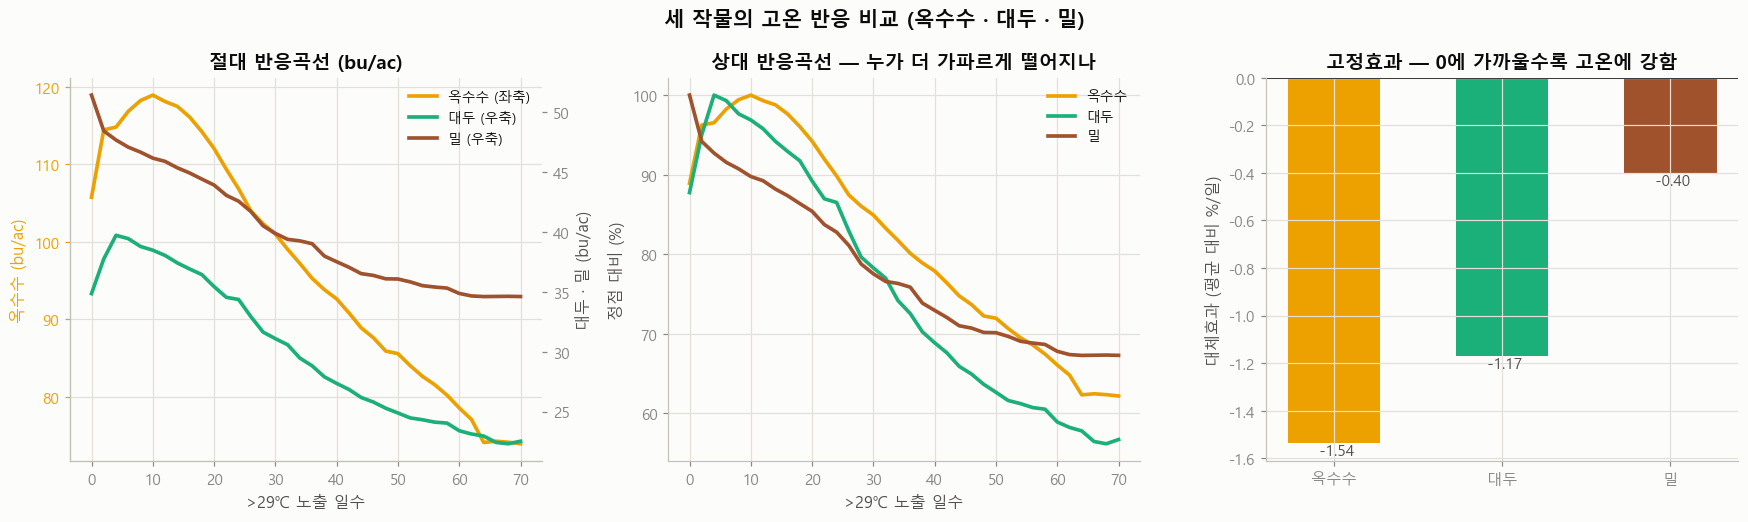

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# (1) 절대 — 각 작물 자기 축
ax = axes[0]; ax.set_axisbelow(True)
r = R['옥수수']
ax.plot(r['vs'][r['keep']], r['curve'][r['keep']], color=CORN_C, lw=2.4, label='옥수수 (좌축)')
ax.set_xlabel('>29℃ 노출 일수'); ax.set_ylabel('옥수수 (bu/ac)', color=CORN_C)
ax.tick_params(axis='y', colors=CORN_C)
ax2 = ax.twinx(); ax2.grid(False)
for k in ['대두', '밀']:
    r = R[k]
    ax2.plot(r['vs'][r['keep']], r['curve'][r['keep']], color=COL[k], lw=2.4, label='%s (우축)' % k)
ax2.set_ylabel('대두 · 밀 (bu/ac)', color=SECOND)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=9)
ax.set_title('절대 반응곡선 (bu/ac)')

# (2) 상대 — 정점 대비 % (같은 축에서 비교 가능)
ax = axes[1]
for k, r in R.items():
    c = r['curve'][r['keep']]; v = r['vs'][r['keep']]
    ax.plot(v, 100 * c / c.max(), color=COL[k], lw=2.4, label=k)
ax.set_xlabel('>29℃ 노출 일수'); ax.set_ylabel('정점 대비 (%)')
ax.set_title('상대 반응곡선 — 누가 더 가파르게 떨어지나')
ax.legend(frameon=False, fontsize=9)

# (3) 고정효과 대체효과 (평균 대비 %/일)
ax = axes[2]
names = cmp3.작물.tolist()
vals = cmp3.대체효과_pct.tolist()
b = ax.bar(names, vals, color=[COL[n] for n in names], width=0.55)
for rr, v in zip(b, vals):
    ax.text(rr.get_x() + rr.get_width() / 2, v, ' %.2f' % v,
            ha='center', va='top' if v < 0 else 'bottom', fontsize=10, color=SECOND)
ax.axhline(0, color=INK, lw=1)
ax.set_ylabel('대체효과 (평균 대비 %/일)')
ax.set_title('고정효과 — 0에 가까울수록 고온에 강함')

fig.suptitle('세 작물의 고온 반응 비교 (옥수수 · 대두 · 밀)', fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig42_temp_response_3crops.png'); plt.show()

## 5. ⚠ year 외삽 편향 정량화 — 밀이 얼마나 과소평가되는가

밀 모델의 학습 연도는 2007까지다. 05/06/10은 `year = 2015` 로 예측한다.
트리 모델은 외삽하지 못하므로 **사실상 2007년 기술 수준**을 반환한다.
그 편향의 크기를 재본다.

In [13]:
# 세 작물의 기술추세 (연도별 전국 평균의 기울기)
print('관측된 기술추세')
TREND = {}
for nm, dfp, col in [('옥수수', cornA, 'corn'), ('대두', soyP, 'soybean'), ('밀', wheat_panel, 'wheat')]:
    g = dfp.groupby('year')[col].mean()
    slope = float(np.polyfit(g.index, g.values, 1)[0])
    TREND[nm] = slope
    print('  %-4s %+.3f bu/ac/년   (%d년 %.1f → %d년 %.1f)'
          % (nm, slope, g.index.min(), g.iloc[0], g.index.max(), g.iloc[-1]))

# year=2007 vs year=2015 로 예측했을 때 밀 예측이 달라지는가 (트리 클램핑 확인)
X_probe = XB.iloc[:3000].copy()
p07 = final_model.predict(X_probe.assign(year=2007))
p15 = final_model.predict(X_probe.assign(year=2015))
print('\n밀 모델에 year=2007 vs year=2015 를 넣으면?')
print('  평균 예측 %.3f vs %.3f bu/ac   차이 %.4f' % (p07.mean(), p15.mean(), p15.mean() - p07.mean()))
print('  최대 절대차 %.4f bu/ac' % np.abs(p15 - p07).max())
if np.abs(p15 - p07).max() < 1e-9:
    print('  → 완전히 동일. 트리가 year를 2007에서 클램핑한다 (외삽 불가 확인).')

lost_yr = 2015 - 2007
print('\n편향 추정: 밀은 %d년치 기술 발전을 못 받는다' % lost_yr)
print('  밀 추세 %+.3f bu/ac/년 × %d년 = %+.2f bu/ac 만큼 과소평가'
      % (TREND['밀'], lost_yr, TREND['밀'] * lost_yr))
print('  (옥수수·대두는 2015년 기술로 예측되므로 이 손해가 없다)')
print('\n→ 10(3작물 최적화)에서 밀이 불리하게 평가된다. §7 한계에 명시.')

관측된 기술추세
  옥수수  +1.774 bu/ac/년   (1981년 87.7 → 2015년 151.1)
  대두   +0.486 bu/ac/년   (1981년 27.8 → 2015년 45.0)
  밀    +0.501 bu/ac/년   (1981년 38.2 → 2007년 46.5)

밀 모델에 year=2007 vs year=2015 를 넣으면?
  평균 예측 50.556 vs 50.556 bu/ac   차이 0.0000
  최대 절대차 0.0000 bu/ac
  → 완전히 동일. 트리가 year를 2007에서 클램핑한다 (외삽 불가 확인).

편향 추정: 밀은 8년치 기술 발전을 못 받는다
  밀 추세 +0.501 bu/ac/년 × 8년 = +4.01 bu/ac 만큼 과소평가
  (옥수수·대두는 2015년 기술로 예측되므로 이 손해가 없다)

→ 10(3작물 최적화)에서 밀이 불리하게 평가된다. §7 한계에 명시.


## 6. 요약

In [14]:
print('=' * 78)
print(' 04c · 밀 수확량 예측 모델 — 요약'.center(78))
print('=' * 78)
print()
print('[1] 데이터')
print('    밀 패널 %s행 / %d 카운티 / %d-%d년'
      % ('{:,}'.format(len(y)), wheat_panel.stco.nunique(),
         wheat_panel.year.min(), wheat_panel.year.max()))
print('    평균 수확량 %.1f bu/ac (옥수수 108.9 · 대두 33.7)' % y.mean())
print('    ⚠ 2008년 이후 관측 없음 — 다른 두 작물보다 8년 짧다')
print()
print('[2] 모델 성능 (GroupKFold(stco) 5-fold)')
print('    최고: %s (전략 %s)  R² %.4f ± %.4f · RMSE %.2f bu/ac · MAE %.2f'
      % (BEST_NAME, BEST_STRAT, BEST['r2_mean'], BEST['r2_std'],
         BEST['rmse_mean'], BEST['mae_mean']))
print('    상대 RMSE %.1f%%  (옥수수 18.4%% · 대두 13.7%%)'
      % (100 * BEST['rmse_mean'] / y.mean()))
print()
print('[3] 세 작물 고온 민감도 (고정효과, T=29℃)')
for _, r in cmp3.iterrows():
    print('    %-4s 대체효과 %+7.4f bu/ac/일  (평균 대비 %+.3f%%/일)  t=%.1f'
          % (r.작물, r.대체효과_bu, r.대체효과_pct, r.t값))
srt = cmp3.sort_values('대체효과_pct', ascending=False)
print('    → 비율 기준 고온 저항성: %s' % ' > '.join(srt.작물.tolist()))
print()
print('[4] ⚠ 한계')
print('    · 밀 학습 연도 1981-2007 → year=2015 예측은 사실상 2007년 기술')
print('      밀이 약 %.1f bu/ac 과소평가된다 (추세 %+.3f × 8년)'
      % (TREND['밀'] * 8, TREND['밀']))
print('    · 온도 노출 창이 3-8월(MarAug) — 옥수수 기준. 겨울밀의 실제 생육창과 어긋난다.')
print()
print('[5] 저장')
print('    data/processed/wheat_panel.parquet')
print('    data/processed/wheat_model_final.joblib')
print('    data/processed/oof_predictions_wheat.parquet')
print('    outputs/results/model_comparison_wheat.csv, fixed_effects_wheat.csv,')
print('                    crop_comparison_3crop.csv')
print('=' * 78)

                            04c · 밀 수확량 예측 모델 — 요약                            

[1] 데이터
    밀 패널 55,847행 / 2674 카운티 / 1981-2007년
    평균 수확량 42.3 bu/ac (옥수수 108.9 · 대두 33.7)
    ⚠ 2008년 이후 관측 없음 — 다른 두 작물보다 8년 짧다

[2] 모델 성능 (GroupKFold(stco) 5-fold)
    최고: LightGBM (전략 B)  R² 0.6908 ± 0.0255 · RMSE 8.78 bu/ac · MAE 6.05
    상대 RMSE 20.8%  (옥수수 18.4% · 대두 13.7%)

[3] 세 작물 고온 민감도 (고정효과, T=29℃)
    옥수수  대체효과 -1.6725 bu/ac/일  (평균 대비 -1.536%/일)  t=-60.7
    대두   대체효과 -0.3945 bu/ac/일  (평균 대비 -1.171%/일)  t=-51.7
    밀    대체효과 -0.1690 bu/ac/일  (평균 대비 -0.399%/일)  t=-20.9
    → 비율 기준 고온 저항성: 밀 > 대두 > 옥수수

[4] ⚠ 한계
    · 밀 학습 연도 1981-2007 → year=2015 예측은 사실상 2007년 기술
      밀이 약 4.0 bu/ac 과소평가된다 (추세 +0.501 × 8년)
    · 온도 노출 창이 3-8월(MarAug) — 옥수수 기준. 겨울밀의 실제 생육창과 어긋난다.

[5] 저장
    data/processed/wheat_panel.parquet
    data/processed/wheat_model_final.joblib
    data/processed/oof_predictions_wheat.parquet
    outputs/results/model_comparison_wheat.csv, fixed_effects_wheat.csv,
                    

## 7. 이상한 점 · 한계

**1. 밀 데이터가 2007년에서 끊긴다 — 가장 큰 제약**
`yielddata.csv` 의 밀은 2008년 이후 관측이 **0건**이다. 원인은 확인하지 못했다(자료 수집 중단인지,
NASS 보고 방식 변경인지). 결과적으로 밀 모델은 **1981–2007** 로만 학습되고,
`year = 2015` 로 예측하면 트리가 외삽하지 못해 **2007년 기술 수준**을 반환한다(§5에서 확인).
옥수수·대두는 2015년 기술로 예측되므로, **10의 3작물 최적화에서 밀이 체계적으로 불리하게
평가된다.** 이 편향은 §5에서 정량화했다.

**대응 방안 두 가지** (10에서 판단):
- (a) 그대로 두고 "밀은 과소평가된 하한"으로 해석 → 밀이 선택되면 그건 진짜다
- (b) 세 작물 모두 `year = 2007` 로 예측해 기술 시대를 맞춤 → 06과 숫자가 달라짐

**2. 생육창(3–8월)이 밀에 맞지 않는다**
온도 노출은 `gddMarAug`(3–8월)를 쓴다. 이는 **옥수수 기준** 생육창이다. 미국 밀의 주력인
**겨울밀은 가을에 파종해 6–7월에 수확**하므로, 밀의 실제 생육 기간(특히 가을·겨울·초봄)이
피처에 전혀 반영되지 않는다. 즉 밀 모델은 **"3–8월 날씨로 밀 수확량을 맞히는" 모델**이며,
인과적 해석은 옥수수·대두보다 훨씬 약하다. 원자료에 봄밀/겨울밀 구분이 없어 분리도 불가능하다.

**3. 그럼에도 밀 모델을 만드는 이유**
3작물 최적화의 목적은 "밀의 수확량을 정확히 예측하는 것"이 아니라 **"선택지를 하나 더 주었을 때
배분이 어떻게 바뀌는가"** 를 보는 것이다. 밀 예측이 다소 부정확해도, 그 부정확성을 명시하고
민감도를 확인하면 최적화 실험으로서의 가치는 남는다. 다만 **"밀을 심어라"는 정책 권고로 읽으면
안 된다.**

**4. 고온 저항성 해석에 주의**
고정효과 대체효과로 세 작물을 비교했지만, 밀의 계수는 **생육창이 어긋난 상태에서 추정된 것**이다.
"밀이 고온에 강하다/약하다"는 결론은 이 한계를 달고 읽어야 한다.